In [9]:
from matplotlib import pyplot as plt
import seaborn as sns
import platform

# OS에 맞춰 한글 폰트 자동 설정
if platform.system() == 'Darwin': # macOS
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
# 마이너스기호 깨짐 방지
plt.rc('axes', unicode_minus=False)
# Seaborn 기본 스타일설정
sns.set_theme(style="whitegrid", font="AppleGothic" if platform.system() == 'Darwin' else "Malgun Gothic")

In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
 
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

In [ ]:
df = pd.read_csv("input.csv", encoding="utf-8-sig")

feature_cols = ["휴일구분", "평균기온", "일강수량", "평균상대습도"]
#feature_cols = df.drop(columns=["전체건수"])
target_col = "전체건수"



X = df[feature_cols]
y = df[target_col]

# 전처리 후 아래 삭제 -----------------------------------
categorical_features = ["휴일구분"]
numeric_features = ["평균기온", "일강수량", "평균상대습도"]
# -----------------------------------


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 전처리 후 아래 삭제 -----------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numeric_features),
    ]
)
# -----------------------------------
models = {
    "Linear Regression": LinearRegression(),
    "Lasso Regression": Lasso(alpha=1.0, random_state=42, max_iter=10000),
    "Ridge Regression": Ridge(alpha=1.0, random_state=42),
    "ElasticNet": ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=42, max_iter=10000),
    "Decision Tree": DecisionTreeRegressor(max_depth=8, random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=300, max_depth=None, random_state=42, n_jobs=-1
    ),
    "SVR": SVR(kernel="rbf", C=100, gamma="scale", epsilon=50),
    "XGBoost": XGBRegressor(
        n_estimators=400, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0
    ),
    "LightGBM": LGBMRegressor(
        n_estimators=400, max_depth=-1, learning_rate=0.05,
        random_state=42, verbosity=-1
    ),
    "CatBoost": CatBoostRegressor(
        iterations=400, depth=6, learning_rate=0.05,
        random_state=42, verbose=0
    ),
}

results = []
predictions = {}
 
for name, model in models.items():
    # 전처리 후 아래 삭제 -----------------------------------
    pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    #  -----------------------------------

    # model.fit(X_train, y_train)
    # y_pred = model.predict(X_test)

    y_pred = np.clip(y_pred, 0, None)
 
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
 
    results.append({"Model": name, "RMSE": rmse, "MAE": mae, "R2": r2})
    predictions[name] = y_pred

results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)

print(results_df)


               Model         RMSE          MAE        R2
0           CatBoost  1510.875184   932.069015  0.619117
1      Random Forest  1537.287768   972.251814  0.605684
2            XGBoost  1577.606256   996.265015  0.584729
3           LightGBM  1639.841482  1037.104953  0.551319
4      Decision Tree  1732.714101  1072.957332  0.499058
5   Ridge Regression  1881.399367  1342.629937  0.409397
6  Linear Regression  1881.483813  1341.929398  0.409344
7   Lasso Regression  1881.764212  1342.265317  0.409168
8                SVR  1939.082104  1182.705504  0.372626
9         ElasticNet  2134.275300  1586.711559  0.239963


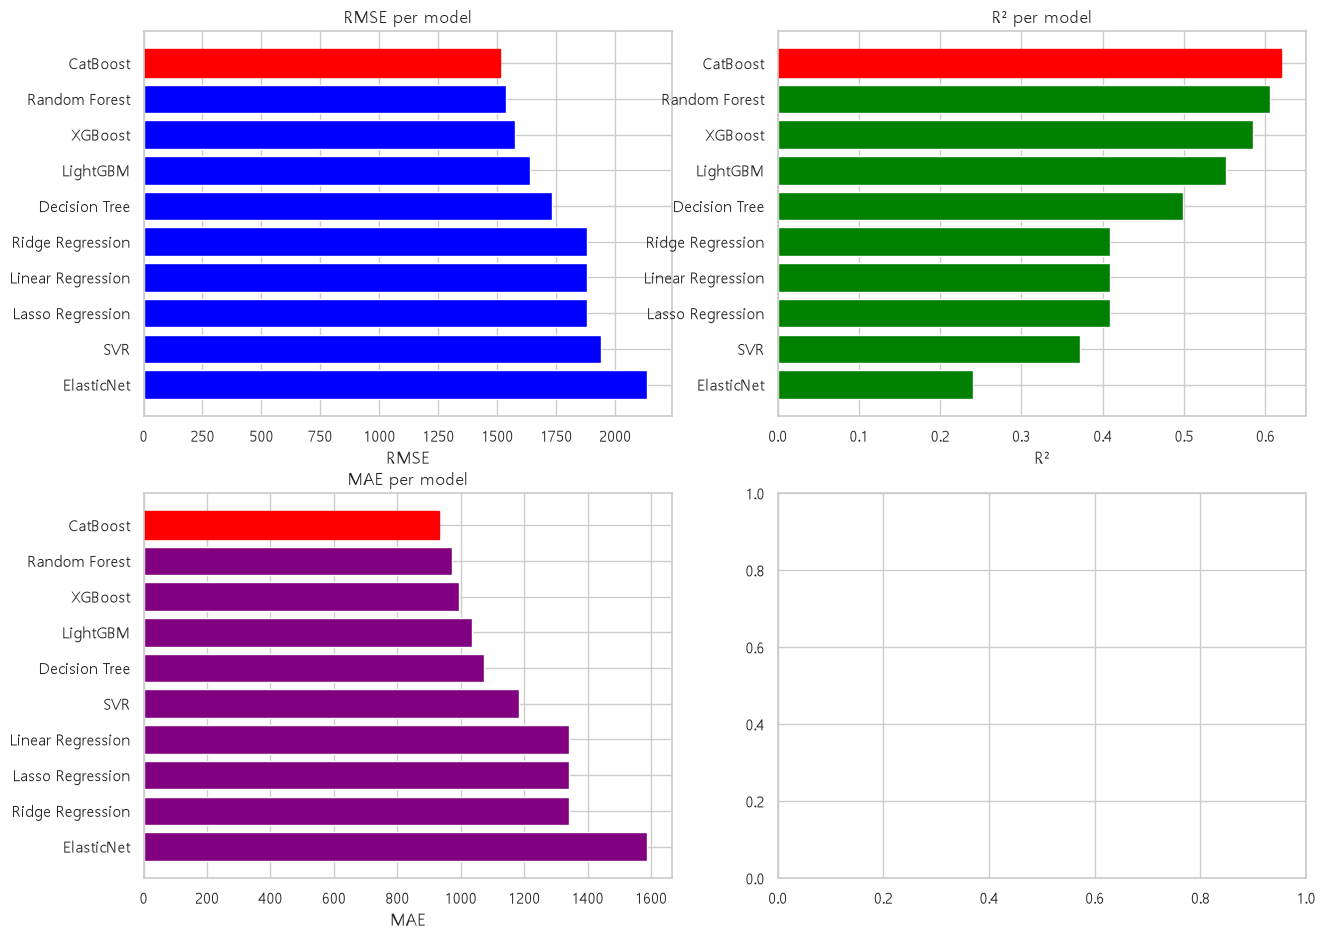

In [23]:
results_sorted = results_df.sort_values("RMSE")
 
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
 
# (1) RMSE 비교
ax = axes[0, 0]
bars = ax.barh(results_sorted["Model"], results_sorted["RMSE"], color="blue")
bars[0].set_color("red")
ax.set_xlabel("RMSE")
ax.set_title("RMSE per model")
ax.invert_yaxis()
 
# (2) R2 비교
ax = axes[0, 1]
results_sorted_r2 = results_df.sort_values("R2", ascending=False)
bars = ax.barh(results_sorted_r2["Model"], results_sorted_r2["R2"], color="green")
bars[0].set_color("red")
ax.set_xlabel("R²")
ax.set_title("R² per model")
ax.invert_yaxis()
 
# (3) MAE 비교
ax = axes[1, 0]
results_sorted_mae = results_df.sort_values("MAE")
bars = ax.barh(results_sorted_mae["Model"], results_sorted_mae["MAE"], color="purple")
bars[0].set_color("red")
ax.set_xlabel("MAE")
ax.set_title("MAE per model")
ax.invert_yaxis()
